# Support Vector Machines

Support Vector Machines approach classification from a different angle than the probabilistic models we've seen. Instead of modeling probabilities, SVMs ask: **what's the best way to draw a line between classes?**

The answer turns out to be: maximize the *margin*. This is the gap between the decision boundary and the nearest points from each class. This geometric intuition leads to a powerful algorithm with strong theoretical guarantees.

**What we'll cover:**
- The margin and why maximizing it makes sense
- Support vectors: the points that matter
- The optimization problem
- Kernel trick: nonlinear boundaries without explicit feature engineering
- Soft margins: handling noise and outliers

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.datasets import make_classification, make_circles, make_moons, make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

ERROR! Session/line number was not unique in database. History logging moved to new session 14


## The Intuition: Which Separator is Best?

Consider a binary classification problem. If the data is linearly separable, there are infinitely many lines that perfectly separate the classes.

Which one should we pick?

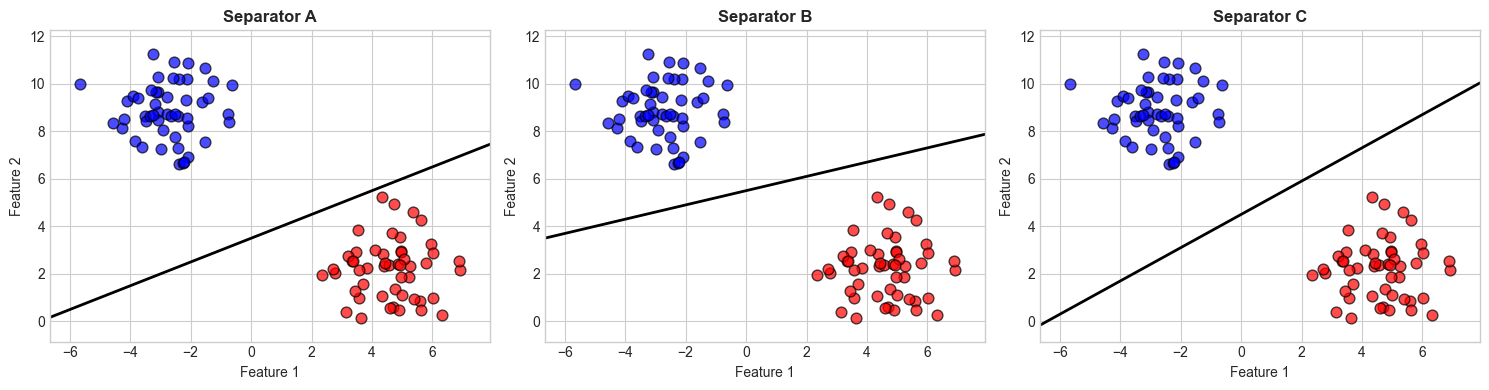

All three lines perfectly separate the training data.
But they'll behave differently on new data.

SVM's answer: choose the one with maximum MARGIN.


In [18]:
# Generate linearly separable data
np.random.seed(42)
X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.2, random_state=42)

# Show multiple valid separators
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

separators = [
    (0.5, 3.5, 'Separator A'),
    (0.3, 5.5, 'Separator B'),
    (0.7, 4.5, 'Separator C'),
]

for ax, (slope, intercept, title) in zip(axes, separators):
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=60, alpha=0.7, edgecolors='k', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red', s=60, alpha=0.7, edgecolors='k', label='Class 1')
    
    x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'k-', linewidth=2)
    
    ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("All three lines perfectly separate the training data.")
print("But they'll behave differently on new data.")
print("\nSVM's answer: choose the one with maximum MARGIN.")

## The Margin

The **margin** is the perpendicular distance from the decision boundary to the nearest point(s) from either class.

**Why maximize it?**

1. **Robustness**: A larger margin means small perturbations in the data are less likely to cause misclassification

2. **Generalization**: Intuitively, a boundary that stays far from all training points is less likely to be an artifact of the specific training set

3. **Theory**: Statistical learning theory (VC dimension bounds) shows that larger margins lead to better generalization guarantees

This is why SVMs are called **maximum margin classifiers**.

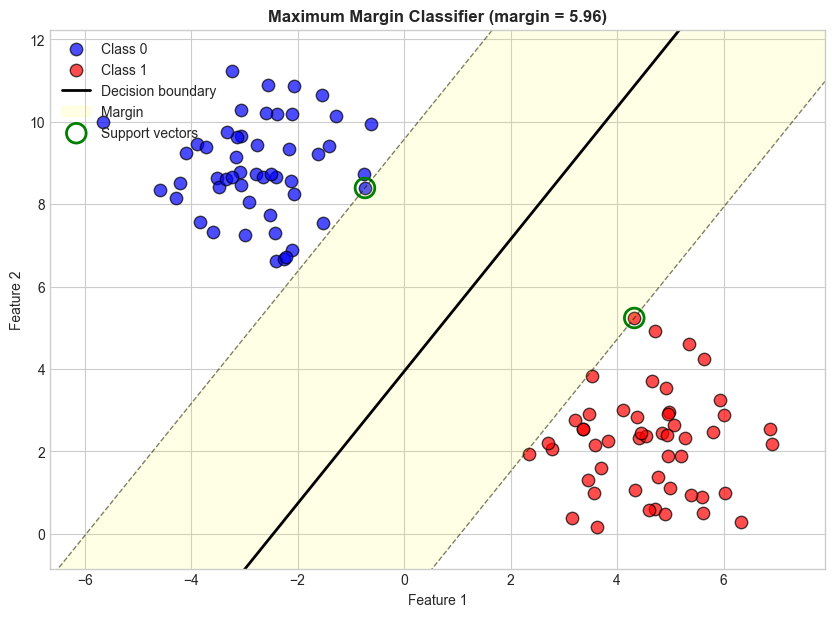

Margin width: 5.961
Number of support vectors: 2


In [19]:
# Train SVM and visualize the margin
svm = SVC(kernel='linear', C=1000)  # Large C for hard margin
svm.fit(X, y)

# Extract decision boundary
w = svm.coef_[0]
b = svm.intercept_[0]

# Decision boundary: w[0]*x + w[1]*y + b = 0
# Solving for y: y = -(w[0]*x + b) / w[1]
x_boundary = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
y_boundary = -(w[0] * x_boundary + b) / w[1]

# Margin boundaries: w[0]*x + w[1]*y + b = +/-1
y_margin_pos = -(w[0] * x_boundary + b - 1) / w[1]
y_margin_neg = -(w[0] * x_boundary + b + 1) / w[1]

# Margin width
margin = 2 / np.linalg.norm(w)

plt.figure(figsize=(10, 7))
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=80, alpha=0.7, edgecolors='k', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', s=80, alpha=0.7, edgecolors='k', label='Class 1')

# Decision boundary
plt.plot(x_boundary, y_boundary, 'k-', linewidth=2, label='Decision boundary')

# Margin boundaries
plt.plot(x_boundary, y_margin_pos, 'k--', linewidth=1, alpha=0.5)
plt.plot(x_boundary, y_margin_neg, 'k--', linewidth=1, alpha=0.5)
plt.fill_between(x_boundary, y_margin_neg, y_margin_pos, alpha=0.1, color='yellow', label='Margin')

# Support vectors
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
           s=200, linewidth=2, facecolors='none', edgecolors='green',
           label='Support vectors')

plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Maximum Margin Classifier (margin = {margin:.2f})', fontweight='bold')
plt.legend(loc='upper left')
plt.show()

print(f"Margin width: {margin:.3f}")
print(f"Number of support vectors: {len(svm.support_vectors_)}")

## Support Vectors

The points that lie exactly on the margin boundaries are called **support vectors**. They're special because:

1. **They define the boundary**: The decision boundary depends *only* on the support vectors
2. **Other points don't matter**: You could remove all non-support-vector points and get the same model
3. **Sparse representation**: Typically only a small fraction of training points become support vectors

This is fundamentally different from logistic regression, where every point influences the boundary.

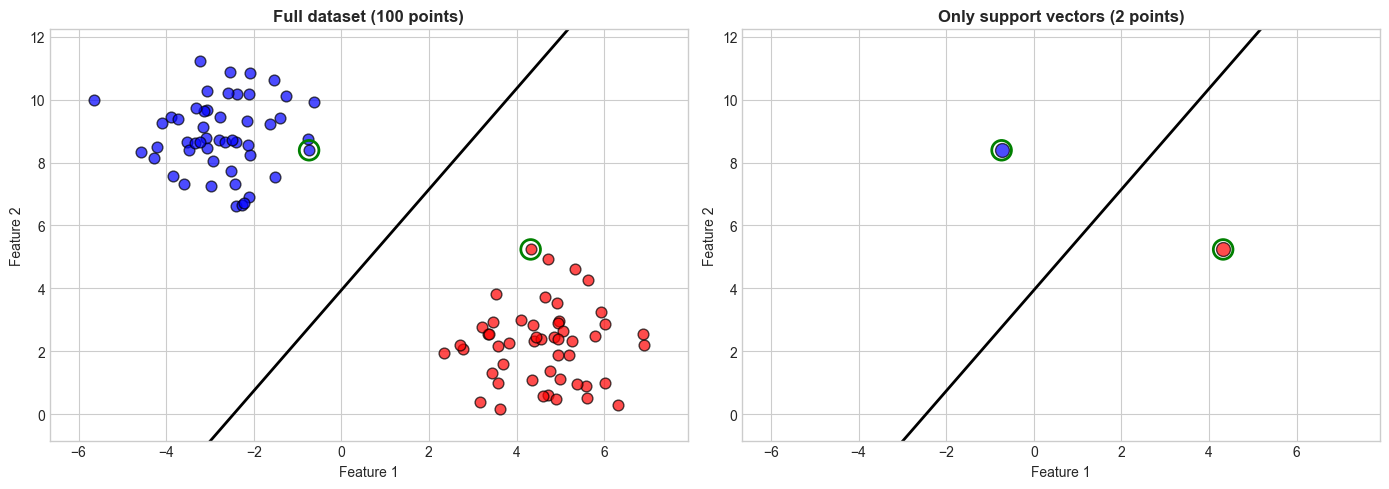

Original weights: w = [0.2847, -0.1776], b = 0.6996
SV-only weights:  w = [0.2847, -0.1776], b = 0.6996

The boundaries are (nearly) identical!


In [20]:
# Demonstrate that only support vectors matter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full dataset
ax = axes[0]
ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=60, alpha=0.7, edgecolors='k')
ax.scatter(X[y==1, 0], X[y==1, 1], c='red', s=60, alpha=0.7, edgecolors='k')
ax.plot(x_boundary, y_boundary, 'k-', linewidth=2)
ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
          s=200, linewidth=2, facecolors='none', edgecolors='green')
ax.set_title(f'Full dataset ({len(X)} points)', fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

# Only support vectors
sv_indices = svm.support_
X_sv = X[sv_indices]
y_sv = y[sv_indices]

svm_sv = SVC(kernel='linear', C=1000)
svm_sv.fit(X_sv, y_sv)

w_sv = svm_sv.coef_[0]
b_sv = svm_sv.intercept_[0]
y_boundary_sv = -(w_sv[0] * x_boundary + b_sv) / w_sv[1]

ax = axes[1]
ax.scatter(X_sv[y_sv==0, 0], X_sv[y_sv==0, 1], c='blue', s=100, alpha=0.7, edgecolors='k')
ax.scatter(X_sv[y_sv==1, 0], X_sv[y_sv==1, 1], c='red', s=100, alpha=0.7, edgecolors='k')
ax.plot(x_boundary, y_boundary_sv, 'k-', linewidth=2)
ax.scatter(X_sv[:, 0], X_sv[:, 1], s=200, linewidth=2, facecolors='none', edgecolors='green')
ax.set_title(f'Only support vectors ({len(X_sv)} points)', fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

plt.tight_layout()
plt.show()

print(f"Original weights: w = [{w[0]:.4f}, {w[1]:.4f}], b = {b:.4f}")
print(f"SV-only weights:  w = [{w_sv[0]:.4f}, {w_sv[1]:.4f}], b = {b_sv:.4f}")
print("\nThe boundaries are (nearly) identical!")

## The Optimization Problem

How do we find the maximum margin hyperplane? It's an optimization problem.

### Setup

A hyperplane is defined by weight vector $\mathbf{w}$ and bias $b$:

$$f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

Points are classified based on the sign of $f(\mathbf{x})$.

### The margin

The distance from a point $\mathbf{x}$ to the hyperplane is:

$$\text{distance} = \frac{|\mathbf{w}^T \mathbf{x} + b|}{||\mathbf{w}||}$$

By convention, we scale $\mathbf{w}$ and $b$ so that for the closest points, $|\mathbf{w}^T \mathbf{x} + b| = 1$.

Then the margin is simply $\frac{1}{||\mathbf{w}||}$.

### The optimization

Maximize margin $\frac{1}{||\mathbf{w}||}$ is equivalent to minimize $||\mathbf{w}||^2$:

$$\min_{\mathbf{w}, b} \frac{1}{2} ||\mathbf{w}||^2$$

Subject to (for all training points $i$):

$$y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1$$

This is a **convex quadratic program** it has a unique global minimum and can be solved efficiently.

## Soft Margins: Handling Non-Separable Data

Real data is rarely perfectly separable. The hard-margin SVM would fail or overfit.

**Solution**: Allow some points to violate the margin, but penalize violations.

Introduce **slack variables** $\xi_i \geq 0$ for each point:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{n} \xi_i$$

Subject to:
$$y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i$$
$$\xi_i \geq 0$$

**The hyperparameter C** controls the trade-off:
- Large C: penalize violations heavily → hard margin (may overfit)
- Small C: tolerate violations → soft margin (may underfit)

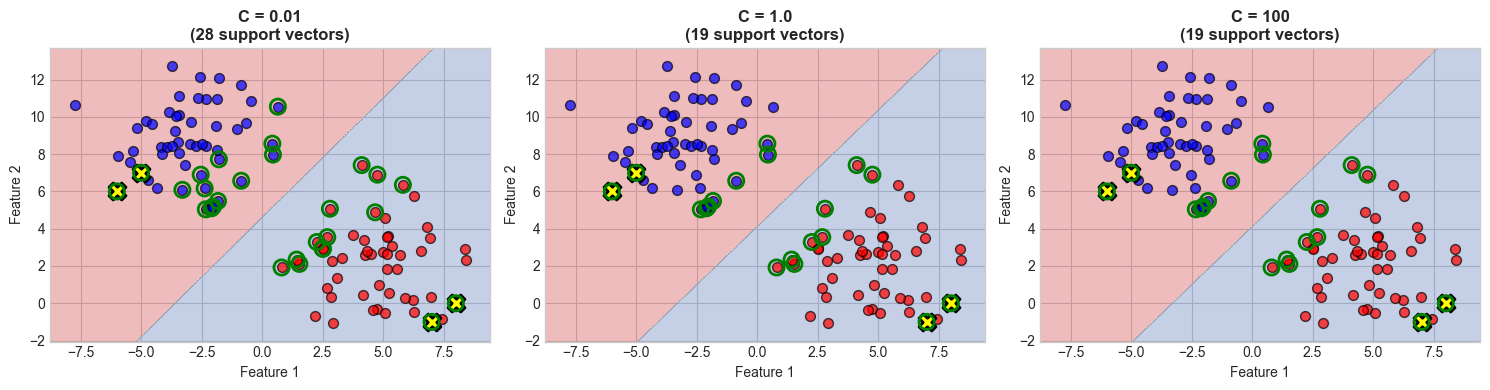

Small C: Ignores outliers, smoother boundary, more support vectors
Large C: Tries to fit outliers, distorted boundary, fewer support vectors


In [21]:
# Generate overlapping data with outliers
np.random.seed(42)
X_overlap, y_overlap = make_blobs(n_samples=100, centers=2, cluster_std=2.0, random_state=42)

# Add some outliers
outliers = np.array([[8, 0], [7, -1], [-6, 6], [-5, 7]])
outlier_labels = np.array([0, 0, 1, 1])  # Wrong side
X_noisy = np.vstack([X_overlap, outliers])
y_noisy = np.hstack([y_overlap, outlier_labels])

# Compare different C values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
C_values = [0.01, 1.0, 100]

for ax, C in zip(axes, C_values):
    svm = SVC(kernel='linear', C=C)
    svm.fit(X_noisy, y_noisy)
    
    # Decision boundary
    h = 0.02
    x_min, x_max = X_noisy[:, 0].min() - 1, X_noisy[:, 0].max() + 1
    y_min, y_max = X_noisy[:, 1].min() - 1, X_noisy[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_overlap[y_overlap==0, 0], X_overlap[y_overlap==0, 1], 
              c='blue', s=50, alpha=0.7, edgecolors='k')
    ax.scatter(X_overlap[y_overlap==1, 0], X_overlap[y_overlap==1, 1], 
              c='red', s=50, alpha=0.7, edgecolors='k')
    ax.scatter(outliers[:, 0], outliers[:, 1], c='yellow', s=150, 
              marker='X', edgecolors='k', linewidths=2, label='Outliers')
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
              s=120, facecolors='none', edgecolors='green', linewidths=2)
    
    ax.set_title(f'C = {C}\n({len(svm.support_vectors_)} support vectors)', fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("Small C: Ignores outliers, smoother boundary, more support vectors")
print("Large C: Tries to fit outliers, distorted boundary, fewer support vectors")

## The Kernel Trick

So far we've only seen linear boundaries. But many problems need nonlinear separation.

### The idea

Map the data to a higher-dimensional space where it becomes linearly separable.

**Example**: Data in 2D forms concentric circles (not linearly separable). Add a third dimension $z = x_1^2 + x_2^2$. Now the inner circle has small $z$, outer circle has large $z$. This is linearly separable!

### The trick

The SVM optimization only needs **dot products** between data points. A **kernel function** $K(\mathbf{x}, \mathbf{x}')$ computes the dot product in the transformed space *without explicitly computing the transformation*.

$$K(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^T \phi(\mathbf{x}')$$

This is computationally efficient even when $\phi$ maps to infinite-dimensional spaces!

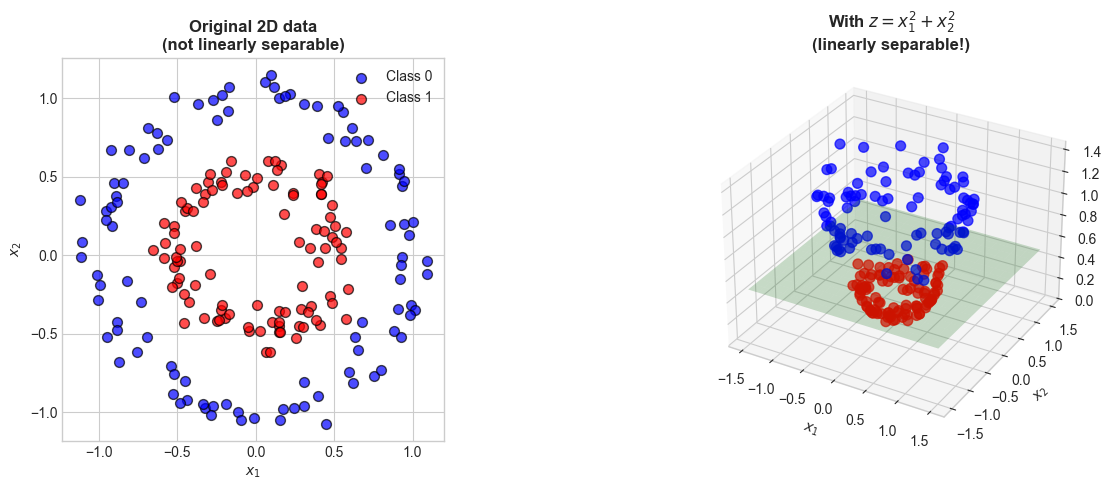

In 3D, a simple plane (green) separates the classes.
The kernel trick does this implicitly!


In [22]:
# Demonstrate: data that needs nonlinear separation
X_circles, y_circles = make_circles(n_samples=200, factor=0.5, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
ax = axes[0]
ax.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], 
          c='blue', s=50, alpha=0.7, edgecolors='k', label='Class 0')
ax.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], 
          c='red', s=50, alpha=0.7, edgecolors='k', label='Class 1')
ax.set_title('Original 2D data\n(not linearly separable)', fontweight='bold')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
ax.set_aspect('equal')

# Transform: add z = x1^2 + x2^2
from mpl_toolkits.mplot3d import Axes3D
ax = fig.add_subplot(1, 2, 2, projection='3d')

z = X_circles[:, 0]**2 + X_circles[:, 1]**2

ax.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], z[y_circles==0],
          c='blue', s=50, alpha=0.7, label='Class 0')
ax.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], z[y_circles==1],
          c='red', s=50, alpha=0.7, label='Class 1')

# Separating plane
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 20), np.linspace(-1.5, 1.5, 20))
zz = np.ones_like(xx) * 0.5  # z = 0.5 separates them
ax.plot_surface(xx, yy, zz, alpha=0.2, color='green')

ax.set_title('With $z = x_1^2 + x_2^2$\n(linearly separable!)', fontweight='bold')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$z$')

# Remove the duplicate first subplot
axes[1].remove()

plt.tight_layout()
plt.show()

print("In 3D, a simple plane (green) separates the classes.")
print("The kernel trick does this implicitly!")

## Common Kernels

| Kernel | Formula | Use case |
|--------|---------|----------|
| **Linear** | $K(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T \mathbf{x}'$ | Linearly separable data, high-dimensional sparse data |
| **Polynomial** | $K(\mathbf{x}, \mathbf{x}') = (\gamma \mathbf{x}^T \mathbf{x}' + r)^d$ | Polynomial relationships, degree $d$ |
| **RBF (Gaussian)** | $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma ||\mathbf{x} - \mathbf{x}'||^2)$ | General nonlinear, most versatile |
| **Sigmoid** | $K(\mathbf{x}, \mathbf{x}') = \tanh(\gamma \mathbf{x}^T \mathbf{x}' + r)$ | Neural network-like |

**RBF is the default choice** it can approximate any continuous function and works well in most cases.

## Summary

| Concept | Description |
|---------|-------------|
| **Margin** | Distance from decision boundary to nearest points |
| **Maximum margin** | SVM finds the boundary that maximizes margin |
| **Support vectors** | Points on the margin that define the boundary |
| **Soft margin (C)** | Allow margin violations; small C = more tolerance |
| **Kernel trick** | Compute in high-dimensional space without explicit transformation |
| **RBF kernel** | Most versatile; $\gamma$ controls influence radius |

**When to use SVM:**
- Clear margin of separation exists
- High-dimensional data (text, genomics)
- Medium-sized datasets
- Need strong theoretical guarantees

**Limitations:**
- Slow on large datasets ($O(n^2)$ to $O(n^3)$)
- Sensitive to feature scaling
- Not directly probabilistic (use Platt scaling for probabilities)
- Many hyperparameters to tune